V(TL)= 14.863870837874158
V(TR)= 14.475496642170018
V(BL)= 19.08774832108501
V(BR)= 0.0
pi(TL)= D
pi(TR)= D
pi(BL)= R
pi(BR)= U but really terminal


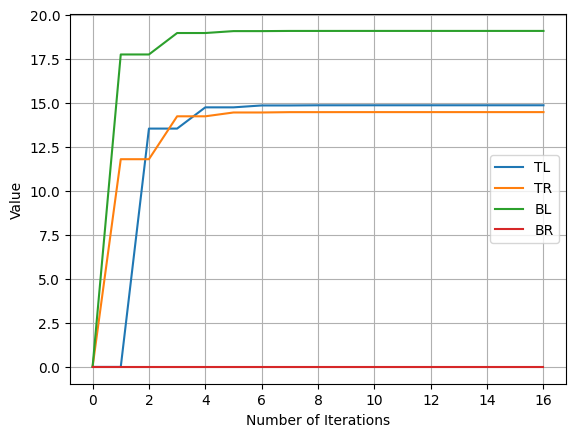

In [1]:
import matplotlib.pyplot as plt
from valueiteration import valueiteration

# Initialise the table and available actions and states
S = ["TL", "TR", "BL", "BR"]
A = ["U", "D", "L", "R"]
results = [
    ["TL", "R", "TR", 0.9, -1],
    ["TL", "R", "BL", 0.1, -2],
    ["TL", "D", "BL", 0.9, -2],
    ["TL", "D", "TR", 0.1, -1],
    ["TR", "L", "TL", 0.9, -1.5],
    ["TR", "L", "BR", 0.1, 10],
    ["TR", "D", "BR", 0.8, 15],
    ["TR", "D", "TL", 0.2, -1],
    ["BL", "R", "BR", 0.9, 20],
    ["BL", "R", "TL", 0.1, -2.5],
    ["BL", "U", "TL", 0.8, -0.5],
    ["BL", "U", "BR", 0.2, 5]]

# Access transition probabilty taken from table, as a function 
def P(s_next, s, a):
    for i in results:
        if i[0] == s and i[1] == a and i[2] == s_next:
            return i[3]
    return 0.0

# Access rewards from the table and calculate expected reward, as a function
def R(s, a):
    reward = 0
    for i in results:
        if i[0] == s and i[1] == a:
            reward += i[3]*i[4]
    return reward

pi, V, k, V_hist = valueiteration(S, A, P, R, threshold=1e-6, gamma=0.9)

# Prints the end results for policy and value
print("V(TL)=", V["TL"])
print("V(TR)=", V["TR"])
print("V(BL)=", V["BL"])
print("V(BR)=", V["BR"])
print("pi(TL)=", pi["TL"])
print("pi(TR)=", pi["TR"])
print("pi(BL)=", pi["BL"])
# This will always take first action in the actions list
print("pi(BR)=", pi["BR"], "but really terminal")

for s in S:
    plt.plot([V[s] for V in V_hist], label=s)

# Plot the results
plt.xlabel("Number of Iterations")
plt.ylabel("Value")
plt.grid()
plt.legend()
plt.show()

__GRID WORLD Problem__

In order to solve the Grid World Problem, I have first started by outlining the transition table given in a way that is easily accessable as I know my package requires P and R in a function format, therefore I have chosen a list of rows and outlining the action and state space for use with the code.

In [2]:
import matplotlib.pyplot as plt
from valueiteration import valueiteration

# Initialise the table and available actions and states
S = ["TL", "TR", "BL", "BR"]
A = ["U", "D", "L", "R"]
results = [
    ["TL", "R", "TR", 0.9, -1],
    ["TL", "R", "BL", 0.1, -2],
    ["TL", "D", "BL", 0.9, -2],
    ["TL", "D", "TR", 0.1, -1],
    ["TR", "L", "TL", 0.9, -1.5],
    ["TR", "L", "BR", 0.1, 10],
    ["TR", "D", "BR", 0.8, 15],
    ["TR", "D", "TL", 0.2, -1],
    ["BL", "R", "BR", 0.9, 20],
    ["BL", "R", "TL", 0.1, -2.5],
    ["BL", "U", "TL", 0.8, -0.5],
    ["BL", "U", "BR", 0.2, 5]]


The next step is to outline the Reward and Transition probability function, these have a similar structure, simply access the corresponding row with action, state and then take the value, or in terms of the reward function, calculates the expected reward by taking the probability of being in a specifc state and multiplying by the corresponding reward, and then summing over all possible s'.

In [3]:
# Access transition probabilty taken from table, as a function 
def P(s_next, s, a):
    for i in results:
        if i[0] == s and i[1] == a and i[2] == s_next:
            return i[3]
    return 0.0

# Access rewards from the table and calculate expected reward, as a function
def R(s, a):
    reward = 0
    for i in results:
        if i[0] == s and i[1] == a:
            reward += i[3]*i[4]
    return reward

The final step to solve the problem with my package is the access the value iteration algorithm, chosing what threshold and gamma (and maxiters if requiring significantly more iterations to converge) you want and then simply print the values and in this case, make a plot of the history of the values over iterations as a feature that I thought would be good for the package to visualise the convergence/termination.

V(TL)= 14.863870837874158
V(TR)= 14.475496642170018
V(BL)= 19.08774832108501
V(BR)= 0.0
pi(TL)= D
pi(TR)= D
pi(BL)= R
pi(BR)= U but really terminal


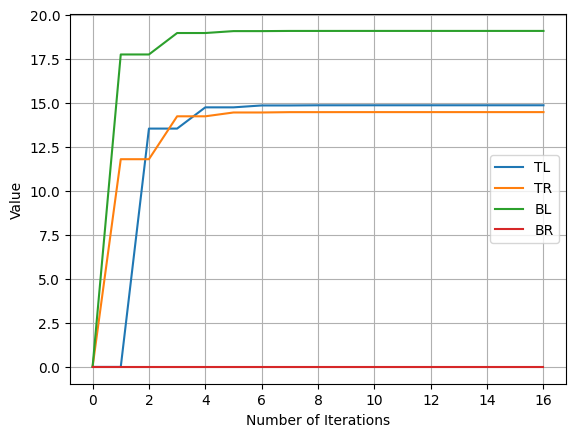

In [5]:
pi, V, k, V_hist = valueiteration(S, A, P, R, threshold=1e-6, gamma=0.9)

# Prints the end results for policy and value
print("V(TL)=", V["TL"])
print("V(TR)=", V["TR"])
print("V(BL)=", V["BL"])
print("V(BR)=", V["BR"])
print("pi(TL)=", pi["TL"])
print("pi(TR)=", pi["TR"])
print("pi(BL)=", pi["BL"])
# This will always take first action in the actions list
print("pi(BR)=", pi["BR"], "but really terminal")

for s in S:
    plt.plot([V[s] for V in V_hist], label=s)

# Plot the results
plt.xlabel("Number of Iterations")
plt.ylabel("Value")
plt.grid()
plt.legend()
plt.show()

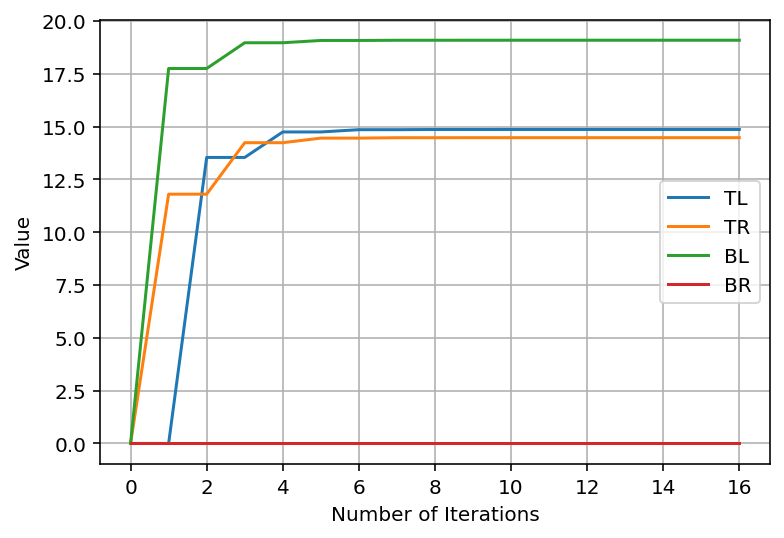

V(TL)= 14.863870837874158

V(TR)= 14.475496642170018

V(BL)= 19.08774832108501

V(BR)= 0.0

pi(TL)= D

pi(TR)= D

pi(BL)= R

pi(BR)= U but really terminal